# Notebook 01 - Orientation and Reference Frames

## Purpose

This notebook introduces the **orientation and reference-frame layer** of HydroLab-3D.

Notebook 00 established trustworthy three-dimensional translational kinematics when vehicle velocity is already known in the **world frame**. Notebook 01 adds the missing geometric relationship between:

- vehicle orientation;
- body-frame motion;
- world-frame motion.

The central objective is to answer:

> **Given a velocity expressed relative to the vehicle itself, and given the vehicle's roll, pitch, and yaw, what velocity does that correspond to in the HydroLab-3D world frame?**

The intended computational chain is:

```text
Body-Frame Velocity
        ↓
Vehicle Orientation
        ↓
Body-to-World Rotation
        ↓
World-Frame Velocity
        ↓
Validated Notebook 00 Position Propagation
        ↓
Updated World-Frame Position
```

This notebook therefore makes **body-relative motion mathematically trustworthy before force-based dynamics are introduced**.

HydroLab-3D follows an algorithm-first, selective-fidelity development philosophy, with reusable mathematical components validated in notebooks before being promoted into the modular simulator package.

---

## Why This Matters

Real robotic vehicles do not normally think about motion only in fixed world coordinates.

Commands such as:

```text
move forward
move backward
move sideways
ascend
descend
```

are naturally interpreted relative to the vehicle's own orientation.

For example, a command to move forward should produce different world-frame motion depending on whether the vehicle is facing:

- along the world $+x$ direction;
- along the world $+y$ direction;
- upward;
- downward;
- or along some arbitrary three-dimensional attitude.

Notebook 00 could already integrate a world-frame velocity:

$$
\mathbf{v}_{world}
$$

into world-frame position.

However, it did not know how to obtain that velocity from a vehicle-relative command.

Notebook 01 therefore introduces the transformation:

$$
\boxed{
\mathbf{v}_{world}
=
R_B^W(\phi,\theta,\psi)
\mathbf{v}_{body}
}
$$

where:

- $\mathbf{v}_{body}$ is translational velocity expressed in the vehicle body frame;
- $\mathbf{v}_{world}$ is the same physical velocity expressed in the world frame;
- $R_B^W$ is the rotation matrix mapping body-frame vectors into world-frame coordinates;
- $\phi$ is roll;
- $\theta$ is pitch;
- $\psi$ is yaw.

Correct reference-frame handling is foundational for essentially every later HydroLab-3D capability involving vehicle dynamics, control, sensing, navigation, or multi-vehicle motion.

---

## What We Will Implement

Notebook 01 will introduce and validate:

- a right-handed HydroLab-3D world coordinate system;
- a right-handed vehicle body coordinate system;
- roll, pitch, and yaw orientation variables;
- elementary rotation matrices;
- a complete roll-pitch-yaw rotation matrix;
- body-frame translational velocity;
- body-to-world velocity transformation;
- inverse world-to-body transformation;
- body-relative trajectory propagation using the validated Notebook 00 translational update;
- mathematical validation of rotation-matrix properties;
- deterministic numerical experiments;
- trajectory and reference-frame visualization;
- persistent orientation/reference-frame validation outputs.

The notebook remains strictly kinematic.

It will **not** introduce forces, accelerations, mass, inertia, hydrodynamics, thrusters, sensors, controllers, ROS 2, or machine learning.

---

## Relationship to Notebook 00

Notebook 00 validated the world-frame translational model:

$$
\dot{\mathbf{p}}
=
\mathbf{v}_{world}
$$

with:

$$
\mathbf{p}
=
\begin{bmatrix}
x\\
y\\
z
\end{bmatrix}.
$$

For a simulation timestep $\Delta t$ during which velocity remains constant, the validated discrete propagation is:

$$
\boxed{
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_{world,k}\Delta t
}
$$

Notebook 00 demonstrated this relation using stationary, single-axis, simultaneous three-axis, and piecewise-constant velocity experiments.

It also demonstrated numerical errors many orders of magnitude below its:

$$
10^{-10}\text{ m}
$$

validation threshold and confirmed deterministic reproducibility.

Notebook 01 does **not replace or redesign** this position integration.

Instead, it adds a new transformation layer immediately upstream:

```text
Notebook 01
Body-Frame Velocity
        ↓
Orientation
        ↓
Body-to-World Transformation
        ↓
World-Frame Velocity
        ↓

Notebook 00
Validated Position Integration
        ↓
World-Frame Position
```

Therefore the translational propagation law inherited from Notebook 00 remains:

$$
\boxed{
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
R_B^W(\phi_k,\theta_k,\psi_k)
\mathbf{v}_{body,k}
\Delta t
}
$$

for a timestep during which orientation and body-frame velocity are treated as constant.

Notebook 01 is responsible for validating the **rotation and reference-frame component** of this expression.

---

# Coordinate and Reference-Frame Convention

The orientation convention defined in this notebook becomes part of the HydroLab-3D mathematical contract.

It must therefore be explicit and remain consistent in later notebooks.

## World Frame

The HydroLab-3D world frame will be denoted:

$$
\mathcal{F}_W.
$$

It is a **right-handed Cartesian coordinate system** with axes:

```text
+x_W : world horizontal x direction
+y_W : world horizontal y direction
+z_W : upward
```

The existing HydroLab-3D vertical convention is retained:

$$
z_W=0
$$

represents the water surface, while ordinary underwater positions satisfy:

$$
z_W<0.
$$

Therefore:

```text
increasing z_W   → upward / toward the surface
decreasing z_W   → downward / deeper underwater
```

This preserves the convention already used by Notebook 00 and the HydroLab-3D project definition.

The world-frame position vector is:

$$
\mathbf{p}_W
=
\begin{bmatrix}
x_W\\
y_W\\
z_W
\end{bmatrix}.
$$

---

## Body Frame

The vehicle-fixed body frame will be denoted:

$$
\mathcal{F}_B.
$$

It is also defined as a **right-handed Cartesian coordinate system**.

Its axes are:

```text
+x_B : forward
+y_B : left
+z_B : upward
```

Therefore:

$$
\hat{\mathbf{x}}_B
\times
\hat{\mathbf{y}}_B
=
\hat{\mathbf{z}}_B.
$$

The corresponding body-frame translational velocity is:

$$
\mathbf{v}_B
=
\begin{bmatrix}
u\\
v\\
w
\end{bmatrix}
$$

where:

- $u$ is forward velocity along $+x_B$;
- $v$ is lateral velocity along $+y_B$;
- $w$ is vertical velocity along $+z_B$.

Thus:

```text
u > 0  → forward
v > 0  → vehicle-left
w > 0  → upward
```

This body-axis choice intentionally preserves both:

1. a right-handed coordinate system; and
2. the existing HydroLab-3D convention that positive vertical motion is upward.

---

## Zero Orientation

At zero orientation:

$$
\phi=0,
\qquad
\theta=0,
\qquad
\psi=0,
$$

the body frame is aligned with the world frame:

$$
\mathcal{F}_B
\equiv
\mathcal{F}_W.
$$

Therefore:

$$
R_B^W(0,0,0)=I_3
$$

and:

$$
\boxed{
\mathbf{v}_{world}
=
\mathbf{v}_{body}
}
$$

at zero orientation.

This identity behavior will be one of the first mandatory validation cases.

---

## Angle Representation

Internally, all orientation mathematics will use **radians**.

Therefore:

$$
\phi,\theta,\psi
\in
\text{radians}.
$$

Degrees may be used in experiments or printed output when they improve readability, but they must be explicitly converted before entering the rotation mathematics.

For example:

$$
90^\circ
=
\frac{\pi}{2}\text{ rad}.
$$

No rotation function will silently interpret degrees as radians or radians as degrees.

---

## Positive Rotation Convention

All positive rotations follow the **right-hand rule** about the positive axis of rotation.

The orientation variables are:

$$
\phi
=
\text{roll about }+x
$$

$$
\theta
=
\text{pitch about }+y
$$

$$
\psi
=
\text{yaw about }+z.
$$

Because the body convention is:

```text
+x_B forward
+y_B left
+z_B upward
```

the signs should be interpreted mathematically through the right-hand rule rather than assumed from conventions used by aircraft or simulators with different axis definitions.

This is especially important for pitch.

Under the HydroLab-3D convention, positive pitch follows the right-hand rule about $+y_B$.

The notebook will validate these directions explicitly instead of relying on verbal intuition alone.

---

# Euler-Angle Convention

Notebook 01 will use roll-pitch-yaw Euler orientation:

$$
(\phi,\theta,\psi).
$$

The body-to-world rotation matrix is defined as:

$$
\boxed{
R_B^W(\phi,\theta,\psi)
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
}
$$

where:

- $R_x(\phi)$ represents roll;
- $R_y(\theta)$ represents pitch;
- $R_z(\psi)$ represents yaw.

This composition corresponds to **intrinsic body-fixed roll, then pitch, then yaw**, equivalently represented by the matrix product:

$$
R_zR_yR_x
$$

when mapping body-frame vector coordinates into the world frame.

The order must not be rearranged later without explicitly redefining the HydroLab-3D orientation convention.

---

## Active Rotation Interpretation

Notebook 01 will use an **active vector-rotation interpretation** for the body-to-world transformation.

The vector:

$$
\mathbf{v}_B
$$

contains the components of a physical velocity relative to the vehicle body axes.

The matrix:

$$
R_B^W
$$

actively maps those components into the fixed world coordinate system:

$$
\boxed{
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B
}
$$

The matrix therefore means:

> **body coordinates to world coordinates.**

The inverse transformation is:

$$
\boxed{
\mathbf{v}_B
=
R_W^B
\mathbf{v}_W
}
$$

with:

$$
R_W^B
=
\left(R_B^W\right)^{-1}.
$$

For a valid rotation matrix:

$$
\left(R_B^W\right)^{-1}
=
\left(R_B^W\right)^T.
$$

Therefore:

$$
\boxed{
\mathbf{v}_B
=
\left(R_B^W\right)^T
\mathbf{v}_W
}
$$

will also be validated numerically.

---

# Mathematical Model

The elementary active rotation matrices will follow the right-hand rule.

## Roll Rotation

Rotation through roll angle $\phi$ about the $x$ axis:

$$
R_x(\phi)
=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\phi & -\sin\phi\\
0 & \sin\phi & \cos\phi
\end{bmatrix}.
$$

---

## Pitch Rotation

Rotation through pitch angle $\theta$ about the $y$ axis:

$$
R_y(\theta)
=
\begin{bmatrix}
\cos\theta & 0 & \sin\theta\\
0 & 1 & 0\\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}.
$$

---

## Yaw Rotation

Rotation through yaw angle $\psi$ about the $z$ axis:

$$
R_z(\psi)
=
\begin{bmatrix}
\cos\psi & -\sin\psi & 0\\
\sin\psi & \cos\psi & 0\\
0 & 0 & 1
\end{bmatrix}.
$$

---

## Complete Body-to-World Rotation

The full orientation transformation is:

$$
\boxed{
R_B^W
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
}
$$

or explicitly:

$$
R_B^W
=
\begin{bmatrix}
c_\psi c_\theta &
c_\psi s_\theta s_\phi-s_\psi c_\phi &
c_\psi s_\theta c_\phi+s_\psi s_\phi
\\
s_\psi c_\theta &
s_\psi s_\theta s_\phi+c_\psi c_\phi &
s_\psi s_\theta c_\phi-c_\psi s_\phi
\\
-s_\theta &
c_\theta s_\phi &
c_\theta c_\phi
\end{bmatrix}
$$

where:

$$
c_\alpha=\cos\alpha
$$

and:

$$
s_\alpha=\sin\alpha.
$$

The world-frame translational velocity is then:

$$
\boxed{
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B
}
$$

with:

$$
\mathbf{v}_B
=
\begin{bmatrix}
u\\
v\\
w
\end{bmatrix}.
$$

The validated Notebook 00 propagation is subsequently applied:

$$
\boxed{
\mathbf{p}_{W,k+1}
=
\mathbf{p}_{W,k}
+
\mathbf{v}_{W,k}\Delta t
}
$$

giving the combined Notebook 00 + Notebook 01 kinematic relation:

$$
\boxed{
\mathbf{p}_{W,k+1}
=
\mathbf{p}_{W,k}
+
R_B^W(\phi_k,\theta_k,\psi_k)
\mathbf{v}_{B,k}
\Delta t
}
$$

This notebook validates that geometric transformation.

It does **not** yet derive orientation from angular velocity or torque.

---

# Expected Result

If the implementation is correct:

1. Zero roll, pitch, and yaw should produce the identity matrix.

2. At zero orientation, body-frame and world-frame velocities should be identical.

3. Pure roll should rotate vectors only within the body/world $yz$ plane.

4. Pure pitch should rotate vectors only within the $xz$ plane.

5. Pure yaw should rotate vectors only within the $xy$ plane.

6. A vehicle commanded to move forward in its body frame should follow different world-frame directions as its orientation changes.

7. Rotations must preserve vector magnitude.

8. Transforming a vector from body to world and then back from world to body should recover the original vector to floating-point precision.

9. Rotation matrices must remain orthogonal and proper:

$$
R^TR=I
$$

and:

$$
\det(R)=+1.
$$

10. World-frame trajectories produced from transformed body-frame velocities should remain deterministic, finite, and geometrically consistent.

---

# Validation Criteria

Notebook 01 will not be considered validated merely because trajectories look visually reasonable.

The orientation implementation must satisfy mathematical and numerical tests.

## 1. Zero-Orientation Test

For:

$$
\phi=\theta=\psi=0
$$

the result must satisfy:

$$
R_B^W=I.
$$

Therefore:

$$
R_B^W\mathbf{v}
=
\mathbf{v}.
$$

---

## 2. Pure-Roll Sanity Test

For:

$$
\theta=0,
\qquad
\psi=0,
$$

the computed transformation must agree with:

$$
R_x(\phi).
$$

Known basis vectors will be rotated and compared against analytically expected directions.

---

## 3. Pure-Pitch Sanity Test

For:

$$
\phi=0,
\qquad
\psi=0,
$$

the computed transformation must agree with:

$$
R_y(\theta).
$$

Known basis vectors will again be used to verify both the axis and sign convention.

---

## 4. Pure-Yaw Sanity Test

For:

$$
\phi=0,
\qquad
\theta=0,
$$

the transformation must agree with:

$$
R_z(\psi).
$$

For example, under the stated convention:

$$
R_z\left(\frac{\pi}{2}\right)
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}.
$$

Thus a vehicle pointing initially along world $+x$ and yawed by positive $90^\circ$ should have its body-forward axis aligned with world $+y$.

---

## 5. Orthogonality Test

A valid rotation matrix must satisfy:

$$
\boxed{
R^TR=I
}
$$

within numerical tolerance.

The residual:

$$
R^TR-I
$$

should therefore remain approximately zero.

---

## 6. Determinant Test

A proper three-dimensional rotation matrix must satisfy:

$$
\boxed{
\det(R)=+1
}
$$

within floating-point tolerance.

This check protects against accidentally introducing reflections or malformed coordinate transformations.

---

## 7. Inverse/Transpose Test

A valid rotation matrix must satisfy:

$$
\boxed{
R^{-1}=R^T
}
$$

within numerical precision.

The notebook will explicitly compare the numerical inverse with the transpose.

---

## 8. Vector-Norm Preservation

Rotation must not change the magnitude of a vector.

For arbitrary:

$$
\mathbf{v},
$$

the notebook must verify:

$$
\boxed{
\|R\mathbf{v}\|
=
\|\mathbf{v}\|
}
$$

within numerical tolerance.

A rotation may change direction.

It may not create or destroy translational speed.

---

## 9. Round-Trip Frame Transformation

For a body-frame vector:

$$
\mathbf{v}_B,
$$

compute:

$$
\mathbf{v}_W
=
R_B^W\mathbf{v}_B
$$

and then:

$$
\hat{\mathbf{v}}_B
=
\left(R_B^W\right)^T
\mathbf{v}_W.
$$

The reconstructed vector must satisfy:

$$
\hat{\mathbf{v}}_B
\approx
\mathbf{v}_B.
$$

---

## 10. Body-Relative Motion Validation

A constant body-frame forward velocity:

$$
\mathbf{v}_B
=
\begin{bmatrix}
u\\
0\\
0
\end{bmatrix}
$$

will be evaluated under multiple known orientations.

The resulting world-frame motion must agree with the analytically predicted directions.

---

## 11. Trajectory Validation

Body-frame commands transformed through orientation and then propagated using the Notebook 00 integration law must produce the expected three-dimensional trajectory.

Where an analytical reference exists, numerical and analytical trajectories will be compared directly.

---

## 12. Numerical Integrity

Generated orientation and trajectory data must contain:

- no NaN values;
- no infinite values;
- valid dimensions;
- strictly increasing timestamps where applicable;
- finite rotation matrices;
- finite transformed velocities;
- finite positions.

---

## 13. Deterministic Reproducibility

Identical:

- initial states;
- orientation histories;
- body-frame velocity commands;
- timesteps;
- simulation lengths

must produce identical numerical trajectories.

---

# Relationship to HydroLab-3D

HydroLab-3D is intended to progressively evolve from simple translational kinematics toward full marine vehicle dynamics.

The repository roadmap places orientation and coordinate transformations immediately after basic 3D kinematics and before force-based dynamics.

The current mathematical lineage is therefore:

```text
Notebook 00
Basic 3D Kinematics

world-frame velocity
        ↓
validated position propagation
        ↓
world-frame position

             │
             ▼

Notebook 01
Orientation and Reference Frames

body-frame velocity
        ↓
vehicle orientation
        ↓
body-to-world rotation
        ↓
world-frame velocity
        ↓
Notebook 00 position propagation
        ↓
world-frame position

             │
             ▼

Notebook 02
Basic Dynamics

force
        ↓
acceleration
        ↓
velocity
        ↓
Notebook 01 frame transformation
        ↓
Notebook 00 position propagation
        ↓
vehicle motion
```

This staged development preserves the HydroLab-3D principle that mathematical components should be individually validated before being composed into more complicated systems.

---

# Scope Boundary

Notebook 01 is limited to **orientation and reference-frame kinematics**.

It may implement:

- Euler-angle representation;
- rotation matrices;
- body/world transformations;
- body-relative translational velocity;
- orientation-dependent translational trajectories.

It will **not** introduce:

```text
force-based dynamics
acceleration dynamics
mass
inertia tensors
torques
angular acceleration
hydrodynamic drag
gravity
buoyancy
thruster physics
ocean-current physics
sensor models
control systems
ROS 2
reinforcement learning
machine-learning infrastructure
```

Angular orientation may be prescribed directly for experiments.

Notebook 01 does not yet need to determine orientation from physical rotational dynamics.

Those capabilities belong to later stages of HydroLab-3D.

---

# Expected Outputs

Notebook 01 is expected to generate only artifacts that contribute directly to orientation/reference-frame validation.

The planned persistent artifacts are:

```text
orientation_history.csv
body_vs_world_velocity.png
oriented_trajectory_3d.png
```

The exact final artifact set may be refined during development if validation demonstrates that an artifact is unnecessary or that an additional artifact is genuinely useful.

No directory or persistent file should be created merely to satisfy a tentative structure.

---

# Output Directory

All persistent Notebook 01 artifacts will be stored beneath:

```text
results/notebooks/01_orientation/
```

Only required subdirectories will be created.

A likely structure is:

```text
results/
└── notebooks/
    └── 01_orientation/
        ├── plots/
        │   ├── body_vs_world_velocity.png
        │   └── oriented_trajectory_3d.png
        │
        └── data/
            └── orientation_history.csv
```

This follows the HydroLab-3D convention that each notebook owns its output directory and creates only the subdirectories it actually requires.

---

# Engineering Handoff Target

The final purpose of Notebook 01 is not merely to produce plots.

It must leave behind a mathematically explicit and validated reference-frame contract that Notebook 02 can safely inherit.

At successful completion, Notebook 01 should establish that HydroLab-3D may assume:

$$
\boxed{
\mathbf{v}_W
=
R_B^W(\phi,\theta,\psi)\mathbf{v}_B
}
$$

with:

$$
\boxed{
R_B^W
=
R_z(\psi)R_y(\theta)R_x(\phi)
}
$$

under the coordinate, sign, Euler-angle, active-rotation, and unit conventions defined above.

Combined with Notebook 00:

$$
\boxed{
\mathbf{p}_{W,k+1}
=
\mathbf{p}_{W,k}
+
R_B^W(\phi_k,\theta_k,\psi_k)
\mathbf{v}_{B,k}
\Delta t
}
$$

will form the validated kinematic foundation inherited by:

```text
02_basic_dynamics.ipynb
```

Notebook 02 may then introduce:

$$
F=ma
$$

and:

$$
\dot{\mathbf{v}}
=
\mathbf{a}
$$

without reopening already validated questions concerning:

- world-frame position propagation;
- body/world coordinate transformation;
- rotation-matrix construction;
- roll-pitch-yaw ordering;
- orientation sign conventions.

The engineering objective of Notebook 01 is therefore:

$$
\boxed{
\text{Make body-to-world motion mathematically trustworthy.}
}
$$

before HydroLab-3D proceeds from kinematics into dynamics.

---

# Step 1 - Numerical Setup

This cell imports the numerical and plotting tools required for Notebook 01.

The notebook will use:

- NumPy for vector and matrix operations;
- Matplotlib for orientation and trajectory visualization;
- Pathlib for output-directory handling.

All orientation calculations will use radians internally.

A small floating-point tolerance is also defined for validating rotation-matrix identities such as:

$$
R^T R = I
$$

and:

$$
\det(R)=1.
$$

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# Numerical display settings
np.set_printoptions(
    precision=6,
    suppress=True
)


# Floating-point validation tolerance
ATOL = 1e-12


# Notebook output locations
OUTPUT_DIR = Path("../results/notebooks/01_orientation")
PLOTS_DIR = OUTPUT_DIR / "plots"
DATA_DIR = OUTPUT_DIR / "data"


print("Notebook 01 numerical environment initialized.")
print(f"Validation tolerance: {ATOL:.1e}")
print(f"Output directory: {OUTPUT_DIR}")

Notebook 01 numerical environment initialized.
Validation tolerance: 1.0e-12
Output directory: ../results/notebooks/01_orientation


# Step 2 - Elementary Rotation Matrices

HydroLab-3D uses right-handed Cartesian coordinate frames.

The elementary active rotation matrices are:

$$
R_x(\phi)
=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\phi & -\sin\phi\\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

$$
R_y(\theta)
=
\begin{bmatrix}
\cos\theta & 0 & \sin\theta\\
0 & 1 & 0\\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}
$$

$$
R_z(\psi)
=
\begin{bmatrix}
\cos\psi & -\sin\psi & 0\\
\sin\psi & \cos\psi & 0\\
0 & 0 & 1
\end{bmatrix}
$$

These matrices will later be composed as:

$$
R_B^W
=
R_z(\psi)R_y(\theta)R_x(\phi).
$$

All angles are expressed in radians.

In [2]:
def rotation_x(phi: float) -> np.ndarray:
    """Active right-handed rotation about the +x axis."""
    c = np.cos(phi)
    s = np.sin(phi)

    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c, -s],
        [0.0, s,  c],
    ])


def rotation_y(theta: float) -> np.ndarray:
    """Active right-handed rotation about the +y axis."""
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [ c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c],
    ])


def rotation_z(psi: float) -> np.ndarray:
    """Active right-handed rotation about the +z axis."""
    c = np.cos(psi)
    s = np.sin(psi)

    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])


# Basic zero-angle sanity check
zero = 0.0

print("R_x(0):")
print(rotation_x(zero))

print("\nR_y(0):")
print(rotation_y(zero))

print("\nR_z(0):")
print(rotation_z(zero))

R_x(0):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]

R_y(0):
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

R_z(0):
[[ 1. -0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]


# Step 3 - Full Roll-Pitch-Yaw Rotation Matrix

HydroLab-3D uses the body-to-world rotation:

$$
R_B^W(\phi,\theta,\psi)
=
R_z(\psi)
R_y(\theta)
R_x(\phi).
$$

This corresponds to roll, pitch, and yaw combined into a single transformation.

The matrix maps a vector expressed in the vehicle body frame into the world frame:

$$
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B.
$$

At zero orientation:

$$
\phi=\theta=\psi=0
$$

the complete rotation matrix must reduce to:

$$
R_B^W = I.
$$

In [3]:
def rotation_body_to_world(
    phi: float,
    theta: float,
    psi: float,
) -> np.ndarray:
    """
    Return the active body-to-world rotation matrix.

    Convention:
        R_B^W = R_z(psi) @ R_y(theta) @ R_x(phi)

    Angles are in radians.
    """
    return (
        rotation_z(psi)
        @ rotation_y(theta)
        @ rotation_x(phi)
    )


# Zero-orientation validation
R_zero = rotation_body_to_world(
    phi=0.0,
    theta=0.0,
    psi=0.0,
)

print("R_B^W(0, 0, 0):")
print(R_zero)

print("\nMatches identity:")
print(np.allclose(R_zero, np.eye(3), atol=ATOL))

R_B^W(0, 0, 0):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Matches identity:
True


# Step 4 - Pure-Axis Rotation Validation

The elementary rotation matrices will now be tested using known $90^\circ$ rotations.

Because all calculations use radians:

$$
90^\circ = \frac{\pi}{2}.
$$

The tests verify that the chosen right-handed sign convention behaves as intended.

For positive yaw:

$$
R_z\left(\frac{\pi}{2}\right)
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}.
$$

For positive pitch:

$$
R_y\left(\frac{\pi}{2}\right)
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
0\\
0\\
-1
\end{bmatrix}.
$$

For positive roll:

$$
R_x\left(\frac{\pi}{2}\right)
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
=
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}.
$$

These tests explicitly validate the HydroLab-3D axis and rotation conventions.

In [5]:
angle_90 = np.pi / 2.0

ex = np.array([1.0, 0.0, 0.0])
ey = np.array([0.0, 1.0, 0.0])

yaw_result = rotation_z(angle_90) @ ex
pitch_result = rotation_y(angle_90) @ ex
roll_result = rotation_x(angle_90) @ ey

expected_yaw = np.array([0.0, 1.0, 0.0])
expected_pitch = np.array([0.0, 0.0, -1.0])
expected_roll = np.array([0.0, 0.0, 1.0])

print("Positive 90° yaw:")
print(yaw_result)
print("Pass:", np.allclose(yaw_result, expected_yaw, atol=ATOL))

print("\nPositive 90° pitch:")
print(pitch_result)
print("Pass:", np.allclose(pitch_result, expected_pitch, atol=ATOL))

print("\nPositive 90° roll:")
print(roll_result)
print("Pass:", np.allclose(roll_result, expected_roll, atol=ATOL))

Positive 90° yaw:
[0. 1. 0.]
Pass: True

Positive 90° pitch:
[ 0.  0. -1.]
Pass: True

Positive 90° roll:
[0. 0. 1.]
Pass: True


# Step 5 - Rotation-Matrix Invariant Validation

A valid three-dimensional rotation matrix must satisfy several mathematical properties.

First, it must be orthogonal:

$$
R^T R = I.
$$

Second, it must represent a proper rotation rather than a reflection:

$$
\det(R)=+1.
$$

Third, its inverse must equal its transpose:

$$
R^{-1}=R^T.
$$

These tests are performed using a non-zero combination of roll, pitch, and yaw so that the validation covers the complete body-to-world rotation matrix rather than only individual axis rotations.

In [6]:
phi_test = np.deg2rad(23.0)
theta_test = np.deg2rad(-17.0)
psi_test = np.deg2rad(41.0)

R_test = rotation_body_to_world(
    phi=phi_test,
    theta=theta_test,
    psi=psi_test,
)

orthogonality_matrix = R_test.T @ R_test
determinant = np.linalg.det(R_test)
inverse_matrix = np.linalg.inv(R_test)

print("Test rotation matrix:")
print(R_test)

print("\nR^T R:")
print(orthogonality_matrix)

print("\nOrthogonality pass:")
print(np.allclose(orthogonality_matrix, np.eye(3), atol=ATOL))

print("\nDeterminant:")
print(determinant)

print("\nDeterminant pass:")
print(np.isclose(determinant, 1.0, atol=ATOL))

print("\nInverse equals transpose:")
print(np.allclose(inverse_matrix, R_test.T, atol=ATOL))

Test rotation matrix:
[[ 0.721732 -0.690123  0.053228]
 [ 0.627392  0.619766 -0.471453]
 [ 0.292372  0.373658  0.880283]]

R^T R:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

Orthogonality pass:
True

Determinant:
1.0000000000000002

Determinant pass:
True

Inverse equals transpose:
True


# Step 6 - Vector-Norm Preservation

A valid rotation changes the direction of a vector without changing its magnitude.

Therefore, for any vector:

$$
\mathbf{v},
$$

a proper rotation matrix must satisfy:

$$
\boxed{
\|R\mathbf{v}\|
=
\|\mathbf{v}\|
}
$$

This property is important because the body-to-world transformation must not artificially increase or decrease vehicle speed.

Only the coordinate representation should change.

In [7]:
v_body_test = np.array([2.5, -1.2, 0.8])

v_world_test = R_test @ v_body_test

norm_body = np.linalg.norm(v_body_test)
norm_world = np.linalg.norm(v_world_test)

print("Body-frame vector:")
print(v_body_test)

print("\nWorld-frame vector:")
print(v_world_test)

print("\nBody-frame norm:")
print(norm_body)

print("\nWorld-frame norm:")
print(norm_world)

print("\nNorm preservation pass:")
print(np.isclose(norm_body, norm_world, atol=ATOL))

Body-frame vector:
[ 2.5 -1.2  0.8]

World-frame vector:
[2.67506  0.447598 0.986766]

Body-frame norm:
2.8861739379323623

World-frame norm:
2.8861739379323623

Norm preservation pass:
True


# Step 7 - Body-to-World-to-Body Round-Trip Validation

The body-to-world transformation is:

$$
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B.
$$

Because a valid rotation matrix satisfies:

$$
(R_B^W)^{-1}
=
(R_B^W)^T,
$$

the inverse transformation is:

$$
\mathbf{v}_B
=
(R_B^W)^T
\mathbf{v}_W.
$$

A correct reference-frame implementation should therefore recover the original body-frame vector after a complete round trip:

$$
\mathbf{v}_B
\rightarrow
\mathbf{v}_W
\rightarrow
\hat{\mathbf{v}}_B.
$$

The reconstructed vector should match the original vector within floating-point tolerance.

In [9]:
v_body_original = np.array([1.7, -0.6, 0.4])

v_world = R_test @ v_body_original

v_body_reconstructed = R_test.T @ v_world

round_trip_error = v_body_reconstructed - v_body_original

print("Original body-frame vector:")
print(v_body_original)

print("\nWorld-frame vector:")
print(v_world)

print("\nReconstructed body-frame vector:")
print(v_body_reconstructed)

print("\nRound-trip error:")
print(round_trip_error)

print("\nRound-trip pass:")
print(
    np.allclose(
        v_body_reconstructed,
        v_body_original,
        atol=ATOL,
    )
)

Original body-frame vector:
[ 1.7 -0.6  0.4]

World-frame vector:
[1.66231  0.506126 0.62495 ]

Reconstructed body-frame vector:
[ 1.7 -0.6  0.4]

Round-trip error:
[ 0. -0.  0.]

Round-trip pass:
True


# Step 8 - Body-Relative Forward Motion Under Known Orientations

A body-frame forward command is represented as:

$$
\mathbf{v}_B
=
\begin{bmatrix}
u\\
0\\
0
\end{bmatrix}.
$$

Its world-frame direction depends on vehicle orientation:

$$
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B.
$$

This test evaluates forward motion under several known orientations.

The expected mappings are:

### Zero Orientation

$$
(\phi,\theta,\psi)=(0,0,0)
$$

$$
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}_B
\rightarrow
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}_W
$$

### Positive 90° Yaw

$$
(\phi,\theta,\psi)=
\left(
0,
0,
\frac{\pi}{2}
\right)
$$

$$
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}_B
\rightarrow
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}_W
$$

### Positive 90° Pitch

$$
(\phi,\theta,\psi)=
\left(
0,
\frac{\pi}{2},
0
\right)
$$

$$
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}_B
\rightarrow
\begin{bmatrix}
0\\
0\\
-1
\end{bmatrix}_W
$$

This directly verifies that a vehicle-relative forward command is correctly interpreted in world coordinates.

In [10]:
v_forward_body = np.array([1.0, 0.0, 0.0])

test_cases = [
    {
        "name": "Zero orientation",
        "phi": 0.0,
        "theta": 0.0,
        "psi": 0.0,
        "expected": np.array([1.0, 0.0, 0.0]),
    },
    {
        "name": "Positive 90° yaw",
        "phi": 0.0,
        "theta": 0.0,
        "psi": np.pi / 2.0,
        "expected": np.array([0.0, 1.0, 0.0]),
    },
    {
        "name": "Positive 90° pitch",
        "phi": 0.0,
        "theta": np.pi / 2.0,
        "psi": 0.0,
        "expected": np.array([0.0, 0.0, -1.0]),
    },
]

for case in test_cases:
    R = rotation_body_to_world(
        phi=case["phi"],
        theta=case["theta"],
        psi=case["psi"],
    )

    v_world = R @ v_forward_body

    passed = np.allclose(
        v_world,
        case["expected"],
        atol=ATOL,
    )

    print(case["name"])
    print("World-frame forward direction:", v_world)
    print("Expected:", case["expected"])
    print("Pass:", passed)
    print()

Zero orientation
World-frame forward direction: [1. 0. 0.]
Expected: [1. 0. 0.]
Pass: True

Positive 90° yaw
World-frame forward direction: [0. 1. 0.]
Expected: [0. 1. 0.]
Pass: True

Positive 90° pitch
World-frame forward direction: [ 0.  0. -1.]
Expected: [ 0.  0. -1.]
Pass: True



# Step 9 - Orientation-Dependent Trajectory

The validated body-to-world transformation is now combined with the translational propagation law from Notebook 00.

For each timestep:

$$
\mathbf{v}_{W,k}
=
R_B^W(\phi_k,\theta_k,\psi_k)
\mathbf{v}_{B,k}
$$

followed by:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_{W,k}\Delta t.
$$

In this experiment:

- body-frame forward speed remains constant;
- roll remains zero;
- pitch remains zero;
- yaw increases smoothly with time.

Because the vehicle continuously changes its heading while moving forward in its own body frame, the world-frame trajectory should curve.

This experiment validates the complete Notebook 01 kinematic chain:

```text
body-frame command
        ↓
orientation
        ↓
body-to-world transformation
        ↓
world-frame velocity
        ↓
position propagation
```

In [11]:
dt = 0.05
duration = 10.0

time = np.arange(
    0.0,
    duration + dt,
    dt,
)

num_steps = len(time)

positions = np.zeros((num_steps, 3))
world_velocities = np.zeros((num_steps, 3))
yaw_history = np.zeros(num_steps)

v_body = np.array([1.0, 0.0, 0.0])

yaw_rate = np.deg2rad(9.0)  # rad/s


for k in range(num_steps):
    psi = yaw_rate * time[k]

    yaw_history[k] = psi

    R = rotation_body_to_world(
        phi=0.0,
        theta=0.0,
        psi=psi,
    )

    world_velocities[k] = R @ v_body

    if k < num_steps - 1:
        positions[k + 1] = (
            positions[k]
            + world_velocities[k] * dt
        )


print("Number of samples:", num_steps)

print("\nInitial position:")
print(positions[0])

print("\nFinal position:")
print(positions[-1])

print("\nFinal yaw [deg]:")
print(np.rad2deg(yaw_history[-1]))

print("\nAll positions finite:")
print(np.all(np.isfinite(positions)))

print("\nAll world velocities finite:")
print(np.all(np.isfinite(world_velocities)))

Number of samples: 201

Initial position:
[0. 0. 0.]

Final position:
[6.391165 6.341165 0.      ]

Final yaw [deg]:
90.0

All positions finite:
True

All world velocities finite:
True


# Step 10 - Analytical Trajectory Validation and Persistent Outputs

The orientation-dependent trajectory can be compared against an analytical reference.

For constant body-frame forward speed:

$$
u = \text{constant}
$$

and constant yaw rate:

$$
\dot{\psi}=\omega,
$$

with:

$$
\psi(0)=0,
$$

the world-frame velocity becomes:

$$
\dot{x}
=
u\cos(\omega t)
$$

and:

$$
\dot{y}
=
u\sin(\omega t).
$$

Integrating analytically gives:

$$
x(t)
=
\frac{u}{\omega}\sin(\omega t)
$$

and:

$$
y(t)
=
\frac{u}{\omega}
\left[
1-\cos(\omega t)
\right].
$$

For a $90^\circ$ turn, the ideal endpoint is therefore:

$$
x_f=y_f=\frac{u}{\omega}.
$$

The numerical trajectory generated using the HydroLab-3D discrete propagation will be compared against this analytical solution.

The notebook will also save its persistent validation artifacts:

- `orientation_history.csv`
- `body_vs_world_velocity.png`
- `oriented_trajectory_3d.png`

These outputs provide the numerical and visual evidence required for the Notebook 01 engineering handoff.

Analytical final position:
[6.366198 6.366198 0.      ]

Numerical final position:
[6.391165 6.341165 0.      ]

Final position error [m]:
0.03535536934959015

Maximum trajectory error [m]:
0.03535536934959015

Trajectory validation pass (< 0.1 m max error):
True


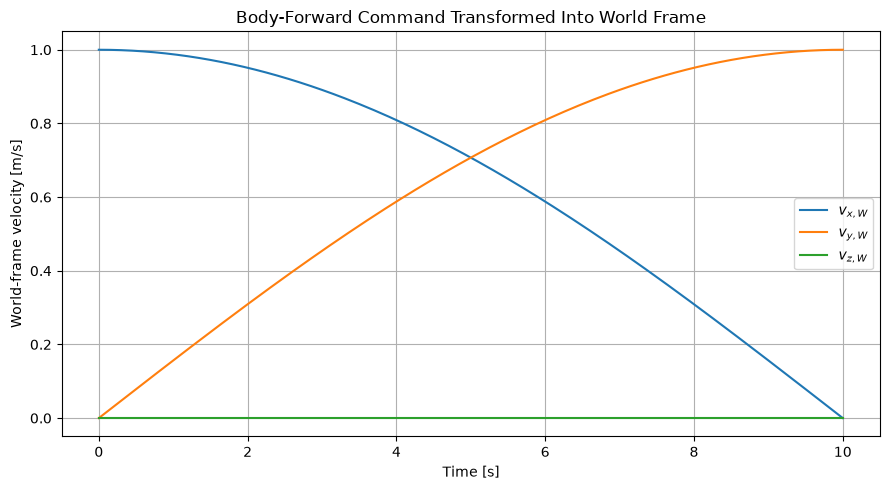

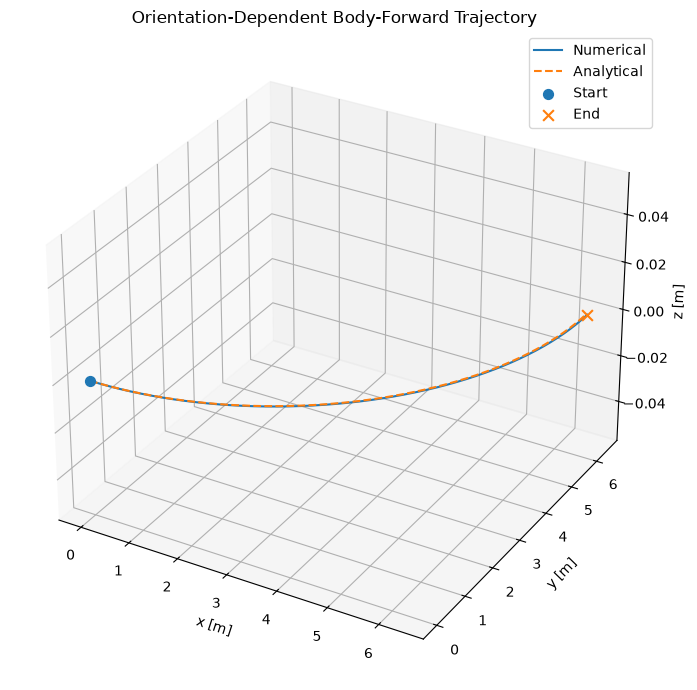


Saved artifacts:
../results/notebooks/01_orientation/data/orientation_history.csv
../results/notebooks/01_orientation/plots/body_vs_world_velocity.png
../results/notebooks/01_orientation/plots/oriented_trajectory_3d.png


In [12]:
# ------------------------------------------------------------------
# Analytical reference trajectory
# ------------------------------------------------------------------

u = v_body[0]
omega = yaw_rate

x_exact = (u / omega) * np.sin(omega * time)
y_exact = (u / omega) * (1.0 - np.cos(omega * time))
z_exact = np.zeros_like(time)

positions_exact = np.column_stack([
    x_exact,
    y_exact,
    z_exact,
])


# Position error relative to analytical solution
position_error = positions - positions_exact

error_norm = np.linalg.norm(
    position_error,
    axis=1,
)

max_position_error = np.max(error_norm)
final_position_error = error_norm[-1]


# Ideal endpoint for the 90-degree turn
ideal_final_position = positions_exact[-1]


print("Analytical final position:")
print(ideal_final_position)

print("\nNumerical final position:")
print(positions[-1])

print("\nFinal position error [m]:")
print(final_position_error)

print("\nMaximum trajectory error [m]:")
print(max_position_error)

print("\nTrajectory validation pass (< 0.1 m max error):")
print(max_position_error < 0.1)


# ------------------------------------------------------------------
# Create persistent output directories
# ------------------------------------------------------------------

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------------
# Save orientation/reference-frame data
# ------------------------------------------------------------------

output_data = np.column_stack([
    time,
    np.rad2deg(yaw_history),
    world_velocities[:, 0],
    world_velocities[:, 1],
    world_velocities[:, 2],
    positions[:, 0],
    positions[:, 1],
    positions[:, 2],
    positions_exact[:, 0],
    positions_exact[:, 1],
    positions_exact[:, 2],
    error_norm,
])

header = (
    "time_s,"
    "yaw_deg,"
    "vx_world_mps,"
    "vy_world_mps,"
    "vz_world_mps,"
    "x_numerical_m,"
    "y_numerical_m,"
    "z_numerical_m,"
    "x_exact_m,"
    "y_exact_m,"
    "z_exact_m,"
    "position_error_m"
)

csv_path = DATA_DIR / "orientation_history.csv"

np.savetxt(
    csv_path,
    output_data,
    delimiter=",",
    header=header,
    comments="",
)


# ------------------------------------------------------------------
# Plot 1: Body-forward command vs world-frame velocity
# ------------------------------------------------------------------

fig = plt.figure(figsize=(9, 5))

plt.plot(
    time,
    world_velocities[:, 0],
    label=r"$v_{x,W}$",
)

plt.plot(
    time,
    world_velocities[:, 1],
    label=r"$v_{y,W}$",
)

plt.plot(
    time,
    world_velocities[:, 2],
    label=r"$v_{z,W}$",
)

plt.xlabel("Time [s]")
plt.ylabel("World-frame velocity [m/s]")
plt.title("Body-Forward Command Transformed Into World Frame")
plt.grid(True)
plt.legend()
plt.tight_layout()

velocity_plot_path = (
    PLOTS_DIR / "body_vs_world_velocity.png"
)

plt.savefig(
    velocity_plot_path,
    dpi=200,
)

plt.show()


# ------------------------------------------------------------------
# Plot 2: Numerical vs analytical 3D trajectory
# ------------------------------------------------------------------

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    positions[:, 0],
    positions[:, 1],
    positions[:, 2],
    label="Numerical",
)

ax.plot(
    positions_exact[:, 0],
    positions_exact[:, 1],
    positions_exact[:, 2],
    linestyle="--",
    label="Analytical",
)

ax.scatter(
    positions[0, 0],
    positions[0, 1],
    positions[0, 2],
    marker="o",
    s=50,
    label="Start",
)

ax.scatter(
    positions[-1, 0],
    positions[-1, 1],
    positions[-1, 2],
    marker="x",
    s=60,
    label="End",
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

ax.set_title(
    "Orientation-Dependent Body-Forward Trajectory"
)

ax.legend()

plt.tight_layout()

trajectory_plot_path = (
    PLOTS_DIR / "oriented_trajectory_3d.png"
)

plt.savefig(
    trajectory_plot_path,
    dpi=200,
)

plt.show()


# ------------------------------------------------------------------
# Output summary
# ------------------------------------------------------------------

print("\nSaved artifacts:")
print(csv_path)
print(velocity_plot_path)
print(trajectory_plot_path)

# Conclusion

## What Was Implemented

Notebook 01 introduced the orientation and reference-frame layer required for body-relative motion in HydroLab-3D.

The notebook implemented:

- right-handed world and vehicle body frames;
- roll, pitch, and yaw orientation variables;
- elementary active rotation matrices:

$$
R_x(\phi),
\qquad
R_y(\theta),
\qquad
R_z(\psi)
$$

- the complete body-to-world rotation matrix:

$$
R_B^W
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
$$

- body-to-world vector transformation:

$$
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B
$$

- world-to-body inverse transformation:

$$
\mathbf{v}_B
=
(R_B^W)^T
\mathbf{v}_W
$$

- orientation-dependent body-relative motion;
- integration of transformed world-frame velocity using the validated Notebook 00 position-propagation law.

The resulting kinematic relationship is:

$$
\boxed{
\mathbf{p}_{W,k+1}
=
\mathbf{p}_{W,k}
+
R_B^W(\phi_k,\theta_k,\psi_k)
\mathbf{v}_{B,k}
\Delta t
}
$$

for timesteps during which orientation and body-frame velocity are treated as constant.

---

## What Was Validated

The orientation implementation was tested at multiple levels.

### Zero-Orientation Identity

For:

$$
\phi=\theta=\psi=0
$$

the complete rotation matrix reduced to:

$$
R_B^W=I
$$

This confirmed that body-frame and world-frame coordinates coincide at zero orientation.

### Pure-Axis Rotations

Known $90^\circ$ rotations were used to verify the axis and sign conventions.

Positive yaw produced:

$$
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
\rightarrow
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
$$

Positive pitch produced:

$$
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
\rightarrow
\begin{bmatrix}
0\\
0\\
-1
\end{bmatrix}
$$

Positive roll produced:

$$
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
\rightarrow
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}
$$

All pure-axis tests passed.

### Rotation-Matrix Properties

A nontrivial combined rotation using:

$$
\phi=23^\circ,
\qquad
\theta=-17^\circ,
\qquad
\psi=41^\circ
$$

was tested.

The resulting matrix satisfied:

$$
R^TR=I
$$

within floating-point tolerance.

Its determinant was:

$$
\det(R)
=
1.0000000000000002
$$

which is numerically equivalent to:

$$
\det(R)=1
$$

The inverse also matched the transpose:

$$
R^{-1}=R^T
$$

### Vector-Norm Preservation

A test body-frame vector:

$$
\mathbf{v}_B
=
\begin{bmatrix}
2.5\\
-1.2\\
0.8
\end{bmatrix}
$$

had magnitude:

$$
\|\mathbf{v}_B\|
=
2.8861739379323623
$$

After transformation into the world frame:

$$
\|\mathbf{v}_W\|
=
2.8861739379323623
$$

Therefore rotation changed direction without changing vector magnitude.

### Body-to-World-to-Body Round Trip

A vector was transformed through:

$$
\mathbf{v}_B
\rightarrow
\mathbf{v}_W
\rightarrow
\hat{\mathbf{v}}_B
$$

The reconstructed body-frame vector matched the original vector to floating-point precision.

### Body-Relative Forward Motion

A constant body-forward command:

$$
\mathbf{v}_B
=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
$$

was tested under several known orientations.

The resulting world-frame directions were:

- zero orientation → $+x_W$
- positive $90^\circ$ yaw → $+y_W$
- positive $90^\circ$ pitch → $-z_W$

All expected mappings were reproduced correctly.

### Orientation-Dependent Trajectory

A vehicle was commanded to move forward at:

$$
u=1\text{ m/s}
$$

while yaw increased at the constant rate:

$$
\dot{\psi}
=
9^\circ/\text{s}
$$

Over:

$$
10\text{ s}
$$

the yaw changed from:

$$
0^\circ
$$

to:

$$
90^\circ
$$

The numerical final position was:

$$
\mathbf{p}_{num}
=
\begin{bmatrix}
6.391165\\
6.341165\\
0
\end{bmatrix}
\text{ m}
$$

The analytical final position was:

$$
\mathbf{p}_{exact}
=
\begin{bmatrix}
6.366198\\
6.366198\\
0
\end{bmatrix}
\text{ m}
$$

The final position error was:

$$
0.0353554\text{ m}
$$

The maximum trajectory error was also:

$$
\boxed{
0.0353554\text{ m}
}
$$

which remained below the validation threshold:

$$
0.1\text{ m}
$$

Therefore the orientation-dependent trajectory validation passed.

---

## Key Results

| Validation | Result |
|---|---|
| Zero-orientation identity | PASS |
| Pure roll rotation | PASS |
| Pure pitch rotation | PASS |
| Pure yaw rotation | PASS |
| $R^TR=I$ | PASS |
| $\det(R)=1$ | PASS |
| $R^{-1}=R^T$ | PASS |
| Vector norm preservation | PASS |
| Body → world → body round trip | PASS |
| Known-orientation forward motion | PASS |
| Numerical trajectory remains finite | PASS |
| Analytical trajectory comparison | PASS |

The maximum trajectory discrepancy during the constant-yaw-rate experiment was approximately:

$$
3.54\text{ cm}
$$

This discrepancy is consistent with the discrete forward-Euler position propagation used in the experiment rather than an error in the rotation transformation itself.

---

## Generated Outputs

Notebook 01 generated the following persistent artifacts:

- `orientation_history.csv`
- `body_vs_world_velocity.png`
- `oriented_trajectory_3d.png`

The CSV contains:

- simulation time;
- yaw angle;
- transformed world-frame velocity components;
- numerical position;
- analytical reference position;
- trajectory error.

The velocity figure demonstrates how a constant body-forward command changes world-frame components as yaw changes.

The trajectory figure compares the numerical body-relative trajectory with the analytical reference solution.

---

## Output Location

All Notebook 01 outputs are stored under:

`results/notebooks/01_orientation/`

The generated files are:

- `results/notebooks/01_orientation/data/orientation_history.csv`
- `results/notebooks/01_orientation/plots/body_vs_world_velocity.png`
- `results/notebooks/01_orientation/plots/oriented_trajectory_3d.png`

---

## Important Observations

The body-to-world transformation behaved correctly for both trivial and nontrivial orientations.

The numerical rotation matrices preserved the defining properties of proper rotations to floating-point precision.

The HydroLab-3D reference-frame convention is now explicitly defined as:

- World $+x_W$: horizontal x direction
- World $+y_W$: horizontal y direction
- World $+z_W$: upward

The vehicle body-frame convention is:

- Body $+x_B$: forward
- Body $+y_B$: left
- Body $+z_B$: upward

Positive rotations follow the right-hand rule.

The Euler-angle composition is:

$$
\boxed{
R_B^W
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
}
$$

All orientation mathematics uses radians internally.

The trajectory experiment also demonstrated that a constant body-forward command can generate curved world-frame motion entirely through changing vehicle orientation.

---

## Current Limitations

Notebook 01 remains purely kinematic.

It does not yet model:

- forces;
- mass;
- acceleration generated by forces;
- inertia;
- moments or torques;
- angular acceleration;
- hydrodynamic effects;
- gravity;
- buoyancy;
- thrusters;
- ocean currents;
- sensors;
- control systems.

Orientation was prescribed directly rather than generated from rotational dynamics.

The notebook also uses Euler angles, which possess a singularity when:

$$
\theta=\pm90^\circ
$$

This does not invalidate the present notebook because its purpose is to establish and validate the initial reference-frame architecture.

More robust orientation representations such as quaternions may be introduced later if HydroLab-3D requires them.

---

## How This Result Will Be Used

The validated reference-frame mathematics now provides the geometric bridge between vehicle-relative motion and world-relative motion.

The reusable transformation logic can later be promoted into the HydroLab-3D source package, potentially under:

`src/hydrolab3d/utils/transforms.py`

or an equivalent location selected when the modular implementation is introduced.

Later vehicle models will be able to generate body-frame velocity from dynamics and then use the validated Notebook 01 transformation to obtain world-frame motion.

The resulting pipeline is:

1. Vehicle dynamics generate body-frame motion.
2. Notebook 01 reference-frame mathematics converts body-frame velocity into world-frame velocity.
3. Notebook 00 integration propagates world-frame position.

---

## Next Notebook

The next development stage is:

`02_basic_dynamics.ipynb`

Notebook 02 will move HydroLab-3D from velocity-prescribed kinematics toward force-based motion.

It will introduce:

$$
F=ma
$$

and therefore:

$$
a=\frac{F}{m}
$$

Velocity will then evolve according to:

$$
\dot{\mathbf{v}}
=
\mathbf{a}
$$

rather than being imposed directly.

The validated results from Notebook 01 allow Notebook 02 to focus specifically on force, acceleration, and velocity evolution without reopening reference-frame geometry.

The mathematical lineage is now:

**Notebook 00**

Validated position propagation

↓

**Notebook 01**

Validated orientation and reference frames

↓

**Notebook 02**

Force-based translational dynamics

Notebook 01 therefore establishes the trusted HydroLab-3D relationship:

$$
\boxed{
\mathbf{v}_W
=
R_B^W
\mathbf{v}_B
}
$$

and, together with Notebook 00:

$$
\boxed{
\mathbf{p}_{W,k+1}
=
\mathbf{p}_{W,k}
+
R_B^W
\mathbf{v}_{B,k}
\Delta t
}
$$

The orientation and reference-frame foundation is now validated and ready for the introduction of dynamics.

---